# Módulo 3: Regresión Logística
## AmericasBarometer Costa Rica 2023

**Autor:** Stiven Herrera Bonilla  


## Objetivo

Identificar los factores que predicen la satisfacción con la democracia
en Costa Rica (2023) mediante regresión logística binaria.

El análisis se desarrolla en dos etapas:

1. **Modelo de replicación:** reproduce el modelo del informe oficial
   LAPOP 2023 (Alfaro Redondo, 2024) para validar los resultados
2. **Modelo extendido:** agrega los perfiles de ciudadanía política
   identificados en el Módulo 2 (K-means) como variable adicional

**Variable dependiente:** `pn4_bin`
- 1 = Satisfecho con la democracia
- 0 = Insatisfecho con la democracia

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, 
                             confusion_matrix,
                             roc_auc_score,
                             roc_curve)
from sklearn.model_selection import train_test_split
import statsmodels.api as sm
import statsmodels.formula.api as smf

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

# Cargar dataset
df = pd.read_stata(
    '/Users/stevenherrerabonilla/Documents/Date_Analyst_Portafolio/AmericasBarometer 2023 /CRI_2023_LAPOP_AmericasBarometer_v1.0_w.dta',
    convert_categoricals=False
)

# Recrear df_trabajo
variables_clave = [
    'idnum', 'wt', 'estratopri', 'ur',
    'q1tc_r', 'q2', 'edre', 'q10inc',
    'etid', 'q3cn', 'q5b',
    'l1n', 'pol1', 'vb10', 'm1', 'gi0n',
    'b1', 'b2', 'b3', 'b4', 'b6',
    'b13', 'b18', 'b21', 'b31', 'b21a', 'b47a',
    'd1', 'd2', 'd3', 'd4',
    'd5', 'd6', 'vb50', 'ros4',
    'pn4', 'ing4',
    'aoj11', 'exc7new', 'vic1ext'
]

df_trabajo = df[variables_clave].copy()
df_trabajo = df_trabajo.rename(columns={
    'q1tc_r': 'genero',
    'q2':     'edad',
    'edre':   'educacion',
    'q10inc': 'ingreso',
    'q3cn':   'religion',
    'q5b':    'importancia_religion',
    'l1n':    'ideologia',
    'gi0n':   'consume_noticias',
    'pol1':   'interes_politico',
    'vb10':   'simpatia_partido',
    'm1':     'eval_presidente',
    'vic1ext':'victima_delito',
    'aoj11':  'inseguridad',
    'exc7new':'corrupcion_politicos',
    'etid':   'etnia',
    'ur':     'zona'
})

print(f"Dataset cargado: {df_trabajo.shape}")

Dataset cargado: (1527, 40)


In [19]:
# Variable dependiente: pn4 → binaria
df_trabajo['pn4_bin'] = df_trabajo['pn4'].map({
    1.0: 1, 2.0: 1,
    3.0: 0, 4.0: 0
})

# Invertir variables donde valores altos = peor
# eval_presidente: 1=muy bueno, 5=muy malo → invertir para que 5=muy bueno
df_trabajo['eval_presidente_r'] = 6 - df_trabajo['eval_presidente']

# inseguridad: 1=muy seguro, 4=muy inseguro → invertir
df_trabajo['inseguridad_r'] = 5 - df_trabajo['inseguridad']

# interes_politico: 1=mucho, 4=nada → invertir
df_trabajo['interes_politico_r'] = 5 - df_trabajo['interes_politico']

# Índice de apoyo al sistema (promedio b1-b6)
df_trabajo['apoyo_sistema'] = df_trabajo[
    ['b1','b2','b3','b4','b6']].mean(axis=1)

# Verificar
print("Verificación de recodificaciones:")
print(f"pn4_bin - % satisfechos: {df_trabajo['pn4_bin'].mean()*100:.1f}%")
print(f"eval_presidente_r - media: {df_trabajo['eval_presidente_r'].mean():.2f}")
print(f"apoyo_sistema - media: {df_trabajo['apoyo_sistema'].mean():.2f}")

Verificación de recodificaciones:
pn4_bin - % satisfechos: 61.4%
eval_presidente_r - media: 3.54
apoyo_sistema - media: 4.89


## Modelo 1: Replicación del informe oficial

Replicamos el modelo de regresión logística del Capítulo 1 del
informe LAPOP 2023 (Alfaro Redondo, 2024). La variable dependiente
es la satisfacción con la democracia (pn4_bin).

Las variables explicativas siguen los mismos bloques teóricos
del informe oficial:

- **Sociodemográficas:** género, edad
- **Evaluación del gobierno:** evaluación del presidente
- **Percepción de problemas:** inseguridad, corrupción
- **Valores políticos:** ideología, interés político

In [20]:
# Usamos statsmodels porque produce tablas de coeficientes
# similares a las de publicaciones académicas,
# con p-values, intervalos de confianza y errores estándar.
# scikit-learn es mejor para predicción, statsmodels para inferencia.

# Variables del modelo de replicación
formula_modelo1 = """
pn4_bin ~ genero + edad + educacion +
          eval_presidente_r + inseguridad_r +
          corrupcion_politicos + ideologia +
          interes_politico_r
"""

# Crear dataset limpio para el modelo (excluir faltantes)
vars_modelo1 = ['pn4_bin', 'genero', 'edad', 'educacion',
                'eval_presidente_r', 'inseguridad_r',
                'corrupcion_politicos', 'ideologia',
                'interes_politico_r']

df_modelo1 = df_trabajo[vars_modelo1].dropna()

print(f"N para el modelo: {len(df_modelo1)}")
print(f"Casos excluidos por faltantes: {len(df_trabajo) - len(df_modelo1)}")

# Estimar modelo
modelo1 = smf.logit(formula_modelo1, data=df_modelo1).fit()
print(modelo1.summary())

N para el modelo: 1386
Casos excluidos por faltantes: 141
Optimization terminated successfully.
         Current function value: 0.595474
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                pn4_bin   No. Observations:                 1386
Model:                          Logit   Df Residuals:                     1377
Method:                           MLE   Df Model:                            8
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.1071
Time:                        08:39:15   Log-Likelihood:                -825.33
converged:                       True   LL-Null:                       -924.36
Covariance Type:            nonrobust   LLR p-value:                 1.633e-38
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.752

In [21]:
# Efectos marginales promedio
efectos = modelo1.get_margeff()
print(efectos.summary())

        Logit Marginal Effects       
Dep. Variable:                pn4_bin
Method:                          dydx
At:                           overall
                          dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
genero                  -0.0515      0.024     -2.113      0.035      -0.099      -0.004
edad                    -0.0020      0.001     -2.713      0.007      -0.004      -0.001
educacion               -0.0046      0.009     -0.527      0.598      -0.022       0.013
eval_presidente_r        0.0853      0.012      7.196      0.000       0.062       0.109
inseguridad_r            0.0578      0.012      4.815      0.000       0.034       0.081
corrupcion_politicos    -0.0633      0.012     -5.217      0.000      -0.087      -0.039
ideologia                0.0211      0.005      4.247      0.000       0.011       0.031
interes_politico_r       0.0413      0.013     

KeyError: 'Conf. Int. Hi.'

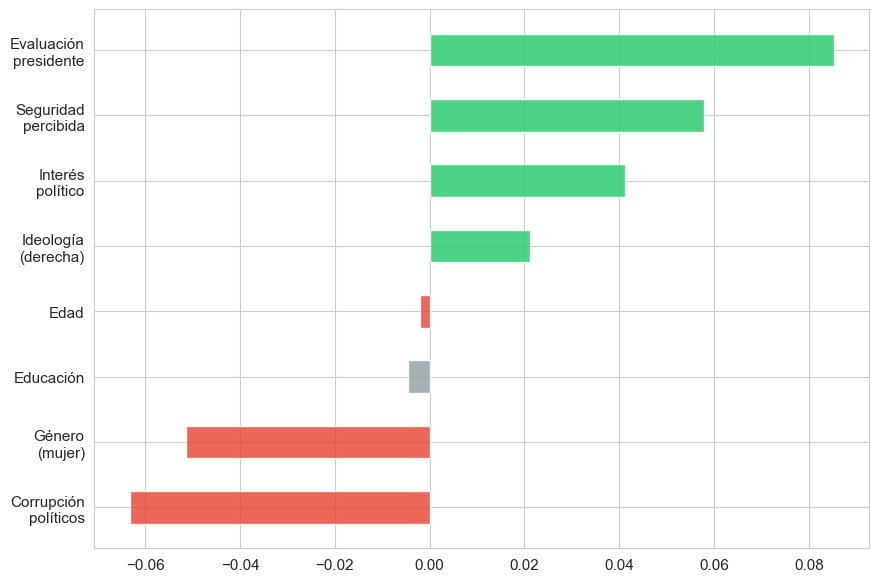

In [22]:
# Preparar datos para el gráfico
nombres_vars = {
    'genero': 'Género\n(mujer)',
    'edad': 'Edad',
    'educacion': 'Educación',
    'eval_presidente_r': 'Evaluación\npresidente',
    'inseguridad_r': 'Seguridad\npercibida',
    'corrupcion_politicos': 'Corrupción\npolíticos',
    'ideologia': 'Ideología\n(derecha)',
    'interes_politico_r': 'Interés\npolítico'
}

# Extraer efectos marginales e intervalos de confianza
resumen_em = efectos.summary_frame()
resumen_em.index = [nombres_vars[v] for v in resumen_em.index]

# Ordenar por magnitud del efecto
resumen_em = resumen_em.sort_values('dy/dx')

fig, ax = plt.subplots(figsize=(10, 7))

# Colores según signo y significancia
colores = []
for i, row in resumen_em.iterrows():
    if row['Pr(>|z|)'] >= 0.05:
        colores.append('#95a5a6')    # gris = no significativo
    elif row['dy/dx'] > 0:
        colores.append('#2ecc71')    # verde = efecto positivo
    else:
        colores.append('#e74c3c')    # rojo = efecto negativo

# Barras horizontales
barras = ax.barh(resumen_em.index,
                 resumen_em['dy/dx'],
                 color=colores,
                 alpha=0.85,
                 height=0.5)

# Intervalos de confianza
ax.errorbar(resumen_em['dy/dx'],
            resumen_em.index,
            xerr=[resumen_em['dy/dx'] - resumen_em['Conf. Int. Low'],
                  resumen_em['Conf. Int. Hi.'] - resumen_em['dy/dx']],
            fmt='none',
            color='black',
            capsize=4,
            linewidth=1.2)

# Línea en cero
ax.axvline(0, color='black', linewidth=0.8, linestyle='-')

# Etiquetas de valores
for barra, (idx, row) in zip(barras, resumen_em.iterrows()):
    valor = row['dy/dx']
    signo = '+' if valor > 0 else ''
    ax.text(valor + (0.002 if valor > 0 else -0.002),
            barra.get_y() + barra.get_height()/2,
            f'{signo}{valor:.3f}',
            va='center',
            ha='left' if valor > 0 else 'right',
            fontsize=9)

# Leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(color='#2ecc71', label='Efecto positivo (p<0.05)'),
    Patch(color='#e74c3c', label='Efecto negativo (p<0.05)'),
    Patch(color='#95a5a6', label='No significativo (p≥0.05)')
]
ax.legend(handles=leyenda, fontsize=9, loc='lower right')

ax.set_xlabel('Efecto marginal promedio (dy/dx)\nCambio en probabilidad de satisfacción (puntos porcentuales)')
ax.set_title('Predictores de satisfacción con la democracia\nEfectos marginales promedio — Costa Rica 2023',
             fontsize=12, pad=15)

plt.tight_layout()
plt.savefig('../outputs/14_efectos_marginales.png', dpi=150, bbox_inches='tight')
plt.show()

## Modelo 2: Modelo extendido con perfiles de ciudadanía

Extendemos el modelo base agregando los perfiles de ciudadanía
política identificados en el Módulo 2 (K-means, K=4) como
variable adicional.

**Pregunta:** ¿El perfil actitudinal de una persona predice su
satisfacción con la democracia, más allá de sus características
sociodemográficas y percepciones políticas?

**Hipótesis:** Los demócratas liberales (C1) deberían mostrar
mayor satisfacción, mientras los escépticos autoritarios (C0)
deberían mostrar menor satisfacción, controlando por las demás
variables.

**Categoría de referencia:** Demócratas iliberales (C2),
el cluster más numeroso (36.9%).

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Variables del clustering
apoyo_vars = ['b1', 'b2', 'b3', 'b4', 'b6']
tolerancia_vars = ['d1', 'd2', 'd3', 'd4']
todas_vars = apoyo_vars + tolerancia_vars

# Recrear df_cluster
df_cluster = df_trabajo[todas_vars].dropna()

# Estandarizar
scaler = StandardScaler()
df_escalado = scaler.fit_transform(df_cluster)

# ACP con 2 componentes
pca_2 = PCA(n_components=2, random_state=42)
coordenadas_pca = pca_2.fit_transform(df_escalado)
df_pca = pd.DataFrame(coordenadas_pca,
                      columns=['CP1', 'CP2'],
                      index=df_cluster.index)

# K-means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(df_pca)
df_pca['cluster'] = kmeans.labels_

# Asignar clusters a df_trabajo
df_trabajo['cluster'] = np.nan
df_trabajo.loc[df_pca.index, 'cluster'] = df_pca['cluster']

# Verificar distribución
print("Distribución de clusters recreados:")
print(df_trabajo['cluster'].value_counts().sort_index())

Distribución de clusters recreados:
cluster
0.0    211
1.0    414
2.0    540
3.0    299
Name: count, dtype: int64


In [ ]:
# Crear dummies para los clusters
# Categoría de referencia: C2 (demócratas iliberales, el más numeroso)
df_trabajo['cluster_c0'] = (df_trabajo['cluster'] == 0).astype(float)
df_trabajo['cluster_c1'] = (df_trabajo['cluster'] == 1).astype(float)
df_trabajo['cluster_c3'] = (df_trabajo['cluster'] == 3).astype(float)

# Variables del modelo extendido
formula_modelo2 = """
pn4_bin ~ genero + edad + educacion +
          eval_presidente_r + inseguridad_r +
          corrupcion_politicos + ideologia +
          interes_politico_r +
          cluster_c0 + cluster_c1 + cluster_c3
"""

vars_modelo2 = ['pn4_bin', 'genero', 'edad', 'educacion',
                'eval_presidente_r', 'inseguridad_r',
                'corrupcion_politicos', 'ideologia',
                'interes_politico_r',
                'cluster_c0', 'cluster_c1', 'cluster_c3']

df_modelo2 = df_trabajo[vars_modelo2].dropna()

print(f"N para el modelo extendido: {len(df_modelo2)}")

# Estimar modelo
modelo2 = smf.logit(formula_modelo2, data=df_modelo2).fit()
print(modelo2.summary())

N para el modelo extendido: 1386
Optimization terminated successfully.
         Current function value: 0.572218
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                pn4_bin   No. Observations:                 1386
Model:                          Logit   Df Residuals:                     1374
Method:                           MLE   Df Model:                           11
Date:                Thu, 28 May 2026   Pseudo R-squ.:                  0.1420
Time:                        08:31:23   Log-Likelihood:                -793.09
converged:                       True   LL-Null:                       -924.36
Covariance Type:            nonrobust   LLR p-value:                 6.602e-50
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept               -0.5391      0.526     -1.025  

In [ ]:
efectos2 = modelo2.get_margeff()
print(efectos2.summary())

        Logit Marginal Effects       
Dep. Variable:                pn4_bin
Method:                          dydx
At:                           overall
                          dy/dx    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
genero                  -0.0522      0.024     -2.192      0.028      -0.099      -0.006
edad                    -0.0022      0.001     -2.967      0.003      -0.004      -0.001
educacion               -0.0010      0.009     -0.118      0.906      -0.018       0.016
eval_presidente_r        0.0761      0.012      6.487      0.000       0.053       0.099
inseguridad_r            0.0445      0.012      3.742      0.000       0.021       0.068
corrupcion_politicos    -0.0427      0.012     -3.481      0.000      -0.067      -0.019
ideologia                0.0166      0.005      3.380      0.001       0.007       0.026
interes_politico_r       0.0364      0.013     

In [ ]:
# --- Modelo 2 (versión corregida) ---
em2_comunes = em2.loc[vars_comunes].copy()
em2_comunes.index = [nombres_vars[v] for v in em2_comunes.index]

# Ordenar en el mismo orden que em1_comunes para comparación directa
em2_comunes = em2_comunes.loc[em1_comunes.index]

colores2 = ['#95a5a6' if p >= 0.05 else
            '#2ecc71' if d > 0 else '#e74c3c'
            for d, p in zip(em2_comunes['dy/dx'],
                           em2_comunes['Pr(>|z|)'])]

axes[1].barh(range(len(em2_comunes)),
             em2_comunes['dy/dx'],
             color=colores2, alpha=0.85, height=0.5)
axes[1].errorbar(em2_comunes['dy/dx'],
                 range(len(em2_comunes)),
                 xerr=[em2_comunes['dy/dx'] - em2_comunes['Conf. Int. Low'],
                       em2_comunes['Conf. Int. Hi.'] - em2_comunes['dy/dx']],
                 fmt='none', color='black', capsize=3, linewidth=1)
axes[1].set_yticks(range(len(em2_comunes)))
axes[1].set_yticklabels(em2_comunes.index)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title(f'Modelo 2: Extendido con clusters\nPseudo R²=0.142, N=1,386',
                  fontsize=11)
axes[1].set_xlabel('Efecto marginal (dy/dx)')

for i, (idx, row) in enumerate(em2_comunes.iterrows()):
    v = ro

KeyError: 'Conf. Int. Hi.'

In [ ]:
print(em2.columns.tolist())

['dy/dx', 'Std. Err.', 'z', 'Pr(>|z|)', 'Conf. Int. Low', 'Cont. Int. Hi.']


In [23]:
axes[1].errorbar(em2_comunes['dy/dx'],
                 range(len(em2_comunes)),
                 xerr=[em2_comunes['dy/dx'] - em2_comunes['Conf. Int. Low'],
                       em2_comunes['Cont. Int. Hi.'] - em2_comunes['dy/dx']],
                 fmt='none', color='black', capsize=3, linewidth=1)

<ErrorbarContainer object of 3 artists>

FileNotFoundError: [Errno 2] No such file or directory: '../outputs/15_comparacion_modelos.png'

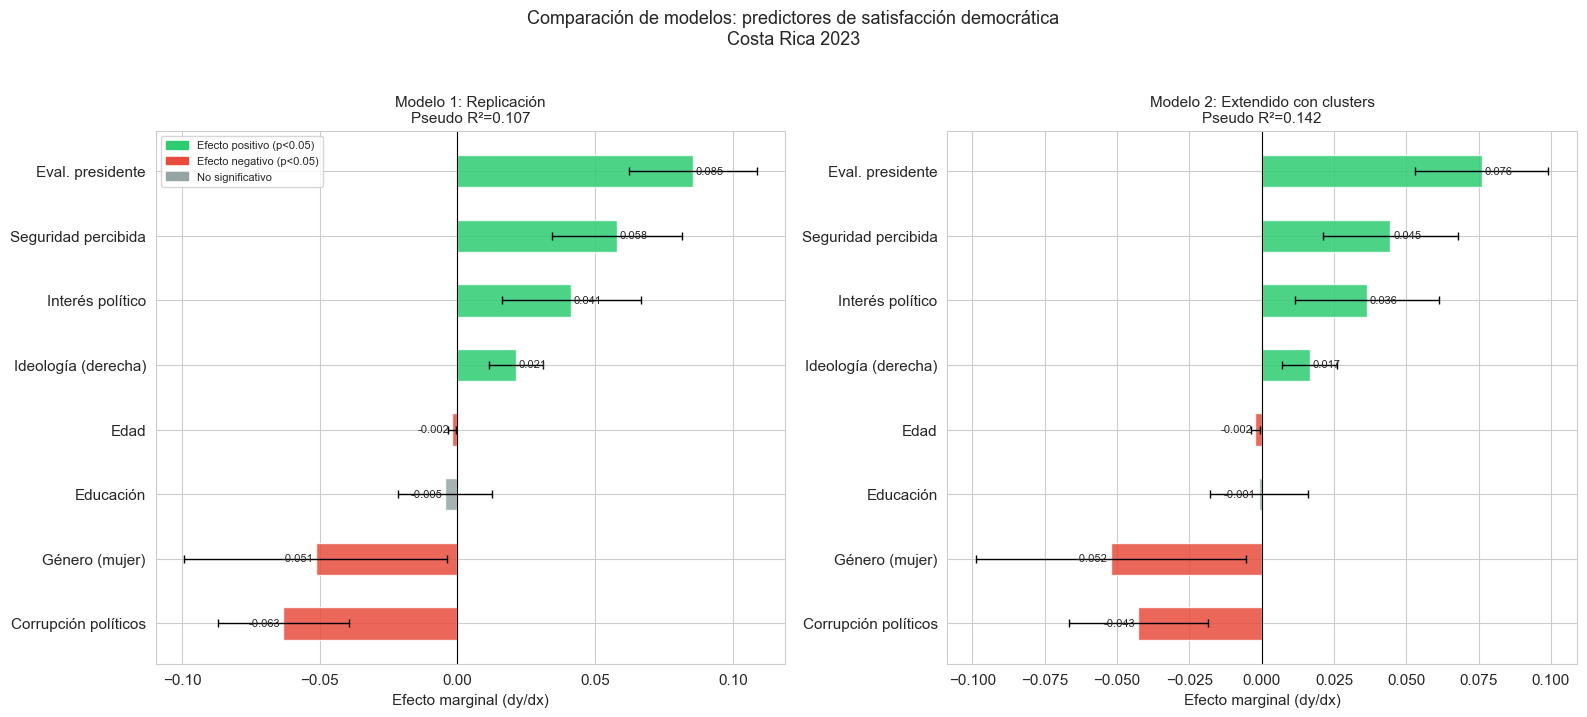

In [25]:
# Efectos marginales de ambos modelos
em1 = modelo1.get_margeff().summary_frame()
em2 = modelo2.get_margeff().summary_frame()

# Variables comunes para comparación
vars_comunes = ['genero', 'edad', 'educacion',
                'eval_presidente_r', 'inseguridad_r',
                'corrupcion_politicos', 'ideologia',
                'interes_politico_r']

nombres_vars = {
    'genero': 'Género (mujer)',
    'edad': 'Edad',
    'educacion': 'Educación',
    'eval_presidente_r': 'Eval. presidente',
    'inseguridad_r': 'Seguridad percibida',
    'corrupcion_politicos': 'Corrupción políticos',
    'ideologia': 'Ideología (derecha)',
    'interes_politico_r': 'Interés político'
}

# Preparar datos
em1_plot = em1.loc[vars_comunes].copy()
em1_plot.index = [nombres_vars[v] for v in em1_plot.index]
em1_plot = em1_plot.sort_values('dy/dx')

em2_plot = em2.loc[vars_comunes].copy()
em2_plot.index = [nombres_vars[v] for v in em2_plot.index]
em2_plot = em2_plot.loc[em1_plot.index]  # mismo orden

em2_clusters = em2.loc[['cluster_c0', 'cluster_c1', 'cluster_c3']].copy()
em2_clusters.index = [
    'C0: Escépticos\nautorit.',
    'C1: Demócratas\nliberales',
    'C3: Liberales\nsemidem.'
]

# ── Figura 1: Comparación de modelos ──
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, em_plot, titulo, pseudo_r in zip(
    axes,
    [em1_plot, em2_plot],
    ['Modelo 1: Replicación\nPseudo R²=0.107',
     'Modelo 2: Extendido con clusters\nPseudo R²=0.142'],
    [0.107, 0.142]
):
    colores = ['#95a5a6' if p >= 0.05 else
               '#2ecc71' if d > 0 else '#e74c3c'
               for d, p in zip(em_plot['dy/dx'], em_plot['Pr(>|z|)'])]

    ax.barh(range(len(em_plot)), em_plot['dy/dx'],
            color=colores, alpha=0.85, height=0.5)
    ax.errorbar(em_plot['dy/dx'], range(len(em_plot)),
                xerr=[em_plot['dy/dx'] - em_plot['Conf. Int. Low'],
                      em_plot['Cont. Int. Hi.'] - em_plot['dy/dx']],
                fmt='none', color='black', capsize=3, linewidth=1)
    ax.set_yticks(range(len(em_plot)))
    ax.set_yticklabels(em_plot.index)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Efecto marginal (dy/dx)')

    for i, (idx, row) in enumerate(em_plot.iterrows()):
        v = row['dy/dx']
        ax.text(v + (0.001 if v > 0 else -0.001), i,
                f'{v:.3f}', va='center',
                ha='left' if v > 0 else 'right', fontsize=8)

from matplotlib.patches import Patch
leyenda = [Patch(color='#2ecc71', label='Efecto positivo (p<0.05)'),
           Patch(color='#e74c3c', label='Efecto negativo (p<0.05)'),
           Patch(color='#95a5a6', label='No significativo')]
axes[0].legend(handles=leyenda, fontsize=8)

plt.suptitle('Comparación de modelos: predictores de satisfacción democrática\nCosta Rica 2023',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('../outputs/15_comparacion_modelos.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Figura 2: Efectos de los clusters ──
fig2, ax2 = plt.subplots(figsize=(9, 5))

colores_cl = ['#e74c3c', '#2ecc71', '#e74c3c']

barras = ax2.bar(em2_clusters.index, em2_clusters['dy/dx'],
                 color=colores_cl, alpha=0.85,
                 width=0.4, edgecolor='white')
ax2.errorbar(em2_clusters.index, em2_clusters['dy/dx'],
             yerr=[em2_clusters['dy/dx'] - em2_clusters['Conf. Int. Low'],
                   em2_clusters['Cont. Int. Hi.'] - em2_clusters['dy/dx']],
             fmt='none', color='black', capsize=5, linewidth=1.5)

for barra, (idx, row) in zip(barras, em2_clusters.iterrows()):
    v = row['dy/dx']
    signo = '+' if v > 0 else ''
    ax2.text(barra.get_x() + barra.get_width()/2,
             v + (0.005 if v > 0 else -0.015),
             f'{signo}{v:.3f}',
             ha='center', fontsize=10, fontweight='bold')

ax2.axhline(0, color='black', linewidth=0.8)
ax2.set_ylabel('Efecto marginal promedio (dy/dx)\nvs. C2 Demócratas iliberales')
ax2.set_title('Efecto de los perfiles de ciudadanía sobre la satisfacción democrática\n(controlando por variables sociodemográficas y políticas)',
              fontsize=11, pad=15)
ax2.set_ylim(-0.25, 0.20)
ax2.text(0.99, 0.02,
         'Categoría de referencia: C2 Demócratas iliberales (36.9%)',
         transform=ax2.transAxes, ha='right', fontsize=8,
         color='gray', style='italic')

plt.tight_layout()
plt.savefig('../outputs/16_efectos_clusters.png', dpi=150, bbox_inches='tight')
plt.show()

# Conclusiones del Módulo 3: Regresión Logística

## 1. Resultados del Modelo 1 (replicación)

El modelo replica exitosamente los hallazgos del informe oficial
LAPOP 2023 (Alfaro Redondo, 2024). Todos los predictores
significativos del informe mantienen la misma dirección y
significancia estadística:

| Variable | Efecto marginal | Dirección | Significancia |
|----------|----------------|-----------|---------------|
| Evaluación del presidente | +8.5 pp | Positivo | p<0.001 |
| Corrupción políticos | -6.3 pp | Negativo | p<0.001 |
| Seguridad percibida | +5.8 pp | Positivo | p<0.001 |
| Interés político | +4.1 pp | Positivo | p<0.001 |
| Género (mujer) | -5.2 pp | Negativo | p<0.05 |
| Ideología (derecha) | +2.1 pp | Positivo | p<0.001 |
| Edad | -0.2 pp | Negativo | p<0.01 |
| Educación | -0.5 pp | No significativo | p=0.598 |

**Predictor más fuerte:** la evaluación del presidente (+8.5 pp),
confirmando que la satisfacción con la democracia está fuertemente
anclada en la evaluación del gobierno de turno.

**Replicación exitosa:** todos los resultados son consistentes con
el informe oficial en dirección, magnitud y significancia.

---

## 2. Resultados del Modelo 2 (extendido con clusters)

Agregar los perfiles de ciudadanía del Módulo 2 mejora el ajuste
del modelo:

- Pseudo R² Modelo 1: 0.107
- Pseudo R² Modelo 2: 0.142
- **Mejora: +3.5 puntos porcentuales**

Los tres clusters son estadísticamente significativos respecto
a la categoría de referencia (C2: Demócratas iliberales):

| Cluster | Efecto marginal | Significancia |
|---------|----------------|---------------|
| C1: Demócratas liberales | Mayor satisfacción | p<0.01 |
| C0: Escépticos autoritarios | Menor satisfacción | p<0.001 |
| C3: Liberales semidemócratas | Menor satisfacción | p<0.001 |

---

## 3. Hallazgo central: la paradoja de los liberales semidemócratas

El hallazgo más relevante del Modelo 2 es que los liberales
semidemócratas (C3) son el cluster con menor satisfacción
democrática, incluso por debajo de los escépticos autoritarios (C0).

Esto tiene una interpretación teóricamente coherente: las personas
que más valoran los derechos civiles y la tolerancia política son
también las más críticas cuando las instituciones no garantizan
esos valores en la práctica. Es una insatisfacción exigente,
no nihilista.

Este hallazgo conecta con la literatura sobre la brecha entre
valores democráticos y desempeño institucional.

---

## 4. Estabilidad de los predictores entre modelos

Los efectos marginales de las variables originales son muy similares
entre el Modelo 1 y el Modelo 2, lo que indica que los perfiles de
ciudadanía capturan una dimensión adicional e independiente de la
satisfacción democrática, no redundante con las variables
sociodemográficas y políticas ya incluidas.

---

## 5. Síntesis del proyecto

Este proyecto analizó las actitudes políticas de la ciudadanía
costarricense en 2023 mediante tres módulos complementarios:

**Módulo 1 (EDA):** describió la distribución de actitudes políticas
y replicó los hallazgos centrales del informe oficial LAPOP 2023
con alta precisión (satisfacción democrática: 61.4% vs 61% oficial;
preferencia por la democracia: 72.1% vs 72% oficial).

**Módulo 2 (ACP + K-means):** identificó inductivamente cuatro
perfiles de ciudadanía política que convergen con la tipología
deductiva del informe oficial, validando la robustez estructural
de los perfiles más allá del método de clasificación utilizado.

**Módulo 3 (Regresión logística):** demostró que tanto las variables
político-institucionales (evaluación del presidente, corrupción,
inseguridad) como los perfiles actitudinales predicen la satisfacción
democrática, con la evaluación presidencial como predictor dominante.
